In [11]:
import pandas as pd 

training_set = pd.read_csv('/home/s6moakba/InstructABSA/Dataset/SemEval14/Train/Laptops_Train.csv')
test_set = pd.read_csv('/home/s6moakba/InstructABSA/Dataset/SemEval14/Test/Laptops_Test.csv')

In [12]:
validation_ratio = 0.1
num_samples = len(training_set)
num_validation_samples = int(validation_ratio * num_samples)

validation_set = training_set.sample(n=num_validation_samples, random_state=42)
training_set = training_set.drop(validation_set.index)

In [13]:
training_set['aspectTerms'] = training_set['aspectTerms'].apply(eval)
validation_set['aspectTerms'] = validation_set['aspectTerms'].apply(eval)
test_set['aspectTerms'] = test_set['aspectTerms'].apply(eval)

In [14]:
def extract_terms(aspect_terms_list):
    terms = []
    for aspect in aspect_terms_list:
        terms.append(aspect['term'])
    return terms

training_set['terms'] = training_set['aspectTerms'].apply(extract_terms)
validation_set['terms'] = validation_set['aspectTerms'].apply(extract_terms)
test_set['terms'] = test_set['aspectTerms'].apply(extract_terms)

In [18]:
def extract_polarity(aspect_terms_list):
    polarity = []
    for aspect in aspect_terms_list:
        polarity.append(aspect['polarity'])
    return polarity

training_set['polarity'] = training_set['aspectTerms'].apply(extract_polarity)
validation_set['polarity'] = validation_set['aspectTerms'].apply(extract_polarity)
test_set['polarity'] = test_set['aspectTerms'].apply(extract_polarity)

In [29]:
rowww = training_set.iloc[60]
print('terms;' , rowww["terms"])
print('polarity; ', rowww['polarity'])
print('raw_text; ', rowww['raw_text'])

terms; ['Drivers', 'BIOS update', 'system']
polarity;  ['positive', 'negative', 'negative']
raw_text;  Drivers updated ok but the BIOS update froze the system up and the computer shut down.


In [5]:
def add_prediction_column(file_path, df):
    with open(file_path, "r") as file:
        content_og = file.read()
    
    lines_og = content_og.split('\n')
    id_tr_labels = eval(lines_og[0].split(': ')[1])
    id_tr_pred_labels = eval(lines_og[1].split(': ')[1])

    df['pred_baseline'] = id_tr_pred_labels
    df['pred_baseline'] = df['pred_baseline'].str.replace(", ", ",")
    df['pred_baseline'] = df['pred_baseline'].apply(lambda x: x.split(','))
    return df


In [6]:
test_set = add_prediction_column('/home/s6moakba/InstructABSA/Label_compare/baseline_test.txt', test_set)
training_set = add_prediction_column('/home/s6moakba/InstructABSA/Label_compare/baseline_training.txt', training_set)
validation_set = add_prediction_column('/home/s6moakba/InstructABSA/Label_compare/baseline_validation.txt', validation_set)

In [7]:
training_terms = set(term for terms_list in training_set['terms'] for term in terms_list)

In [8]:
validation_set['tp'] = validation_set.apply(lambda row: 1 if sorted(row['terms']) == sorted(row['pred_baseline']) else 0, axis=1)
test_set['tp'] = test_set.apply(lambda row: 1 if sorted(row['terms']) == sorted(row['pred_baseline']) else 0, axis=1)

In [9]:
test_set['in_train'] = test_set['terms'].apply(lambda terms: all(term in training_terms for term in terms))
test_set['in_train'] = test_set['in_train'].astype(int)

In [10]:
test_set

,sentenceId,raw_text,aspectTerms,aspectCategories,terms,pred_baseline,tp,in_train
0,32897564#894393#2,The bread is top notch as well.,"[{'term': 'bread', 'polarity': 'positive'}]","[{'category': 'food', 'polarity': 'positive'}]",[bread],[bread],1,1
1,33070600#670328#0,I have to say they have one of the fastest del...,"[{'term': 'delivery times', 'polarity': 'posit...","[{'category': 'service', 'polarity': 'positive'}]",[delivery times],[delivery times],1,0
2,33070600#670328#2,Food is always fresh and hot- ready to eat!,"[{'term': 'Food', 'polarity': 'positive'}]","[{'category': 'food', 'polarity': 'positive'}]",[Food],[Food],1,1
3,36244464#949326#5,Did I mention that the coffee is OUTSTANDING?,"[{'term': 'coffee', 'polarity': 'positive'}]","[{'category': 'food', 'polarity': 'positive'}]",[coffee],[coffee],1,1
4,32894246#870052#0,"Certainly not the best sushi in New York, howe...","[{'term': 'sushi', 'polarity': 'conflict'}, {'...","[{'category': 'food', 'polarity': 'conflict'},...","[sushi, place]","[sushi, place]",1,1
...,...,...,...,...,...,...,...,...
795,11661949#1709112#8,"Anyway, the owner was fake.","[{'term': 'owner', 'polarity': 'negative'}]","[{'category': 'service', 'polarity': 'negative'}]",[owner],[owner],1,1
796,35698240#574381#2,Owner is pleasant and entertaining.,"[{'term': 'Owner', 'polarity': 'positive'}]","[{'category': 'service', 'polarity': 'positive'}]",[Owner],[Owner],1,1
797,11350390#802808#3,"I have never in my life sent back food before,...","[{'term': 'food', 'polarity': 'negative'}, {'t...","[{'category': 'food', 'polarity': 'negative'},...","[food, waiter]","[food, waiter]",1,1
798,11482070#503858#3,"Although the restaurant itself is nice, I pref...","[{'term': 'food', 'polarity': 'negative'}]","[{'category': 'ambience', 'polarity': 'positiv...",[food],[food],1,1


In [11]:
test_set_relevant = test_set.drop(columns=['aspectTerms', 'sentenceId', 'aspectCategories'])
test_set_relevant

,raw_text,terms,pred_baseline,tp,in_train
0,The bread is top notch as well.,[bread],[bread],1,1
1,I have to say they have one of the fastest del...,[delivery times],[delivery times],1,0
2,Food is always fresh and hot- ready to eat!,[Food],[Food],1,1
3,Did I mention that the coffee is OUTSTANDING?,[coffee],[coffee],1,1
4,"Certainly not the best sushi in New York, howe...","[sushi, place]","[sushi, place]",1,1
...,...,...,...,...,...
795,"Anyway, the owner was fake.",[owner],[owner],1,1
796,Owner is pleasant and entertaining.,[Owner],[Owner],1,1
797,"I have never in my life sent back food before,...","[food, waiter]","[food, waiter]",1,1
798,"Although the restaurant itself is nice, I pref...",[food],[food],1,1


In [12]:
test_set_relevant

,raw_text,terms,pred_baseline,tp,in_train
0,The bread is top notch as well.,[bread],[bread],1,1
1,I have to say they have one of the fastest del...,[delivery times],[delivery times],1,0
2,Food is always fresh and hot- ready to eat!,[Food],[Food],1,1
3,Did I mention that the coffee is OUTSTANDING?,[coffee],[coffee],1,1
4,"Certainly not the best sushi in New York, howe...","[sushi, place]","[sushi, place]",1,1
...,...,...,...,...,...
795,"Anyway, the owner was fake.",[owner],[owner],1,1
796,Owner is pleasant and entertaining.,[Owner],[Owner],1,1
797,"I have never in my life sent back food before,...","[food, waiter]","[food, waiter]",1,1
798,"Although the restaurant itself is nice, I pref...",[food],[food],1,1


In [13]:
'Focacchia bread' in training_terms

False

In [10]:
test_set_same = test_set[test_set['tp'] == 1]
test_set_diff = test_set[test_set['tp'] == 0]

In [11]:
print('right answers in validation set:', len(test_set_same))
print('wrong answers in validation:', len(test_set_diff))

right answers in validation set: 661
wrong answers in validation: 139


In [12]:
print('out of', len(test_set_same),'right answers ', len(test_set_same[test_set_same['in_train'] == 1]), 'had trems in training set')
print('out of', len(test_set_diff),'wrong answers ', len(test_set_diff[test_set_diff['in_train'] == 1]), 'had trems in training set')

out of 661 right answers  486 had trems in training set
out of 139 wrong answers  62 had trems in training set


In [18]:
terms_not_in_train = set()
for index, row in test_set_diff[test_set_diff['in_train'] == 0].iterrows():
    terms_not_in_train.update(row['terms'])
terms_not_in_train 

{'"Roy\'s Classics"',
 'BANANA PUDDING',
 'CRABCAKES',
 'Churrasco',
 'Creamy appetizers',
 'Cuisine',
 'Desserts',
 'Dishes',
 'Egg McMuffin sandwich',
 'Focacchia bread',
 'Food',
 'Fresh veggies',
 'Greek yogurt (with cuccumber, dill, and garlic)',
 'Hibiscus lemonade',
 'Jerusalem market-style falafel wraps',
 'LASAGNA',
 'MAC AND CHEESE',
 'Mediterranean salads--layered with beets, goat cheese and walnuts',
 'Ribs',
 'Seafood Paella for two',
 'Tart of the Day',
 'Waiting',
 '[female] servers',
 'afternoon snack',
 'apple tart',
 'argentine chorizo appetizer',
 'array of sushi',
 'asian fusion',
 'assortment of wraps',
 'atmosphere',
 'back patio',
 'beef',
 'bi-level space',
 'big mac',
 'bill',
 'billed',
 'blue bar area',
 'booth by the windows',
 'boutique selection of wines',
 'breakfast',
 'burgers',
 'burrito',
 'cake',
 'casual drink',
 'casual lunches',
 'cheese',
 'cheese baclava',
 'chicken',
 'chicken and falafel platters',
 'chicken tacos',
 'chocolate Frosty',
 'choc

In [22]:
import string

# Define a function to check if a term contains any punctuation
def contains_punctuation(term):
    return any(char in string.punctuation for char in term)

# Filter the terms that contain punctuation
terms_with_punctuation = [term for term in terms_not_in_train if contains_punctuation(term)]

# Count the number of terms with punctuation
num_terms_with_punctuation = len(terms_with_punctuation)
print(len(terms_not_in_train))
print(num_terms_with_punctuation)

print(string.punctuation)

174
14
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [21]:
# Define a function to check if a term contains any capital letters
def contains_capital_letters(term):
    return any(char.isupper() for char in term)

# Filter the terms that contain capital letters
terms_with_capital_letters = [term for term in terms_not_in_train if contains_capital_letters(term)]

# Count the number of terms with capital letters
num_terms_with_capital_letters = len(terms_with_capital_letters)
print(num_terms_with_capital_letters)

27


In [13]:
test_set_diff

,sentenceId,raw_text,aspectTerms,aspectCategories,terms,pred_baseline,tp,in_train
14,11359717#1138929#3,The sangria's - watered down.,"[{'term': 'sangria', 'polarity': 'negative'}]","[{'category': 'food', 'polarity': 'negative'}]",[sangria],[sangrias],0,1
18,35390148#588852#2,The portions of the food that came out were me...,"[{'term': 'portions of the food', 'polarity': ...","[{'category': 'food', 'polarity': 'neutral'}]",[portions of the food],[portions of food],0,0
19,11351513#832512#1,the two waitress's looked like they had been s...,"[{'term': 'waitress's', 'polarity': 'negative'}]","[{'category': 'service', 'polarity': 'negative'}]",[waitress's],[waitress],0,0
20,11313431#524365#2,"From the beginning, we were met by friendly st...","[{'term': 'staff memebers', 'polarity': 'posit...","[{'category': 'service', 'polarity': 'positive...","[staff memebers, parking]","[staff, parking, staff]",0,0
22,35196527#481646#2,Desserts are almost incredible: my personal fa...,"[{'term': 'Desserts', 'polarity': 'positive'},...","[{'category': 'food', 'polarity': 'positive'}]","[Desserts, Tart of the Day]",[Desserts],0,0
...,...,...,...,...,...,...,...,...
775,32899282#556036#1,They are served on Focacchia bread and are to ...,"[{'term': 'served', 'polarity': 'neutral'}, {'...","[{'category': 'food', 'polarity': 'positive'}]","[served, Focacchia bread]",[Focacchia bread],0,0
778,11432442#650772#2,"The guac is fresh, yet lacking flavor, we like...","[{'term': 'guac', 'polarity': 'conflict'}, {'t...","[{'category': 'food', 'polarity': 'conflict'}]","[guac, fresh salsa, flavor]","[guac, flavor, salsa]",0,0
779,11313290#1139539#1,"The new menu has a few creative items,they wer...","[{'term': 'prices', 'polarity': 'negative'}, {...","[{'category': 'food', 'polarity': 'positive'},...","[prices, staff, new menu]","[menu, items, prices, staff]",0,0
794,32443281#959917#4,Its good to go there for drinks if you don't w...,"[{'term': 'service', 'polarity': 'negative'}, ...","[{'category': 'service', 'polarity': 'negative'}]","[service, drink, drinks]","[drinks, service]",0,1


In [29]:
all_terms_set = set(term for terms_list in test_set_diff['terms'] for term in terms_list)
multi_word_terms = {term for term in all_terms_set if len(term.split()) > 1}
multi_word_terms

{'"Roy\'s Classics"',
 'BANANA PUDDING',
 'Creamy appetizers',
 'Egg McMuffin sandwich',
 'Focacchia bread',
 'Fresh veggies',
 'Greek yogurt (with cuccumber, dill, and garlic)',
 'Hibiscus lemonade',
 'Jerusalem market-style falafel wraps',
 'MAC AND CHEESE',
 'Mediterranean salads--layered with beets, goat cheese and walnuts',
 'Seafood Paella for two',
 'Tart of the Day',
 '[female] servers',
 'afternoon snack',
 'apple tart',
 'argentine chorizo appetizer',
 'array of sushi',
 'asian fusion',
 'assortment of wraps',
 'back patio',
 'bi-level space',
 'big mac',
 'blue bar area',
 'booth by the windows',
 'boutique selection of wines',
 'casual drink',
 'casual lunches',
 'cheese baclava',
 'chicken and falafel platters',
 'chicken tacos',
 'chocolate Frosty',
 'chocolate raspberry cake',
 'choices of sauces',
 'coconut rice',
 'cold sesame noodles',
 'creme brulee',
 'disco pop duo',
 'display and quality of the food',
 'eggplant salad',
 'fennel flavored Italian sausage',
 'fortun

In [33]:
all_terms_set = set(term for terms_list in training_set['terms'] for term in terms_list)
multi_word_terms = {term for term in all_terms_set if len(term.split()) > 1}
multi_word_terms

{"'gourmet' Indian cuisine",
 '2-person table',
 'AT MOSHPHERE',
 "Abby's treasure",
 'American Chinese food',
 'Angry Lobster',
 'Argentinian Pizza',
 'Asian appetizers',
 'BBQ Salmon',
 'BBQ ribs',
 'Barbecued codfish',
 'Beef Cube on rice',
 'Beef noodle soup',
 'Blue Fin Torro (Fatty Tuna)',
 'Blue Point oysters',
 'Bombay beer',
 'Boton Shrimp',
 'Cakebread Cabernet',
 'Change Mojito',
 'Cheese plate',
 'Chicken Teriyaki dish',
 'Chicken Tikka Masala',
 'Chicken pad tai',
 'Chicken with Cashew Nuts',
 'Chilean Sea Bass',
 'Chinese food',
 'Christmas dinner',
 'Crab Croquette apt',
 'Crispy Duck',
 'Dal Bukhara',
 'Deep Fried Skewers',
 'Delivery service',
 'Dim Sum',
 'Downstairs lounge',
 'FOOD PORTIONS',
 'Fatty Yellow Tail',
 'Filet Mignon',
 'Filet Mignon with garlic mash',
 'Fluke sashimi',
 'French bistro fare',
 'French food',
 'General Tao chicken',
 'Go Go Hamburgers',
 'Godmother pizza',
 'Godmother pizza (a sort of traditional flat pizza with an olive oil-brushed crust 

In [14]:
s_test_diff = test_set_diff[test_set_diff['terms'].apply(len) == 3]
sampled_same_df = s_test_diff.sample(n=20, random_state=6)
for row in sampled_same_df.iterrows():
    print("sentence : ",row[1]['raw_text'])
    print("Labels:" , row[1]['aspectTerms'])
    print("baseline prediction :" ,row[1]['pred_baseline'])

sentence :  this is still one of my most favorite restaurants in the area the food is inexpensive but very good (kimono shrimp special was excellent) and has a great atmosphere.
Labels: [{'term': 'food', 'polarity': 'positive'}, {'term': 'kimono shrimp special', 'polarity': 'positive'}, {'term': 'atmosphere', 'polarity': 'positive'}]
baseline prediction : ['food', 'atmosphere']
sentence :  A mix of students and area residents crowd into this narrow, barely there space for its quick, tasty treats at dirt-cheap prices.
Labels: [{'term': 'space', 'polarity': 'negative'}, {'term': 'prices', 'polarity': 'positive'}, {'term': 'treats', 'polarity': 'positive'}]
baseline prediction : ['treats', 'prices']
sentence :  The traditional Italian items are great - cheap and served in a cozy setting.
Labels: [{'term': 'traditional Italian items', 'polarity': 'positive'}, {'term': 'setting', 'polarity': 'positive'}, {'term': 'served', 'polarity': 'positive'}]
baseline prediction : ['Italian items', 'se

# Plots

/tmp/ipykernel_1735962/821678740.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set_same['terms_length'] = test_set_same['terms'].apply(len)
/tmp/ipykernel_1735962/821678740.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set_diff['terms_length'] = test_set_diff['terms'].apply(len)
/tmp/ipykernel_1735962/821678740.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

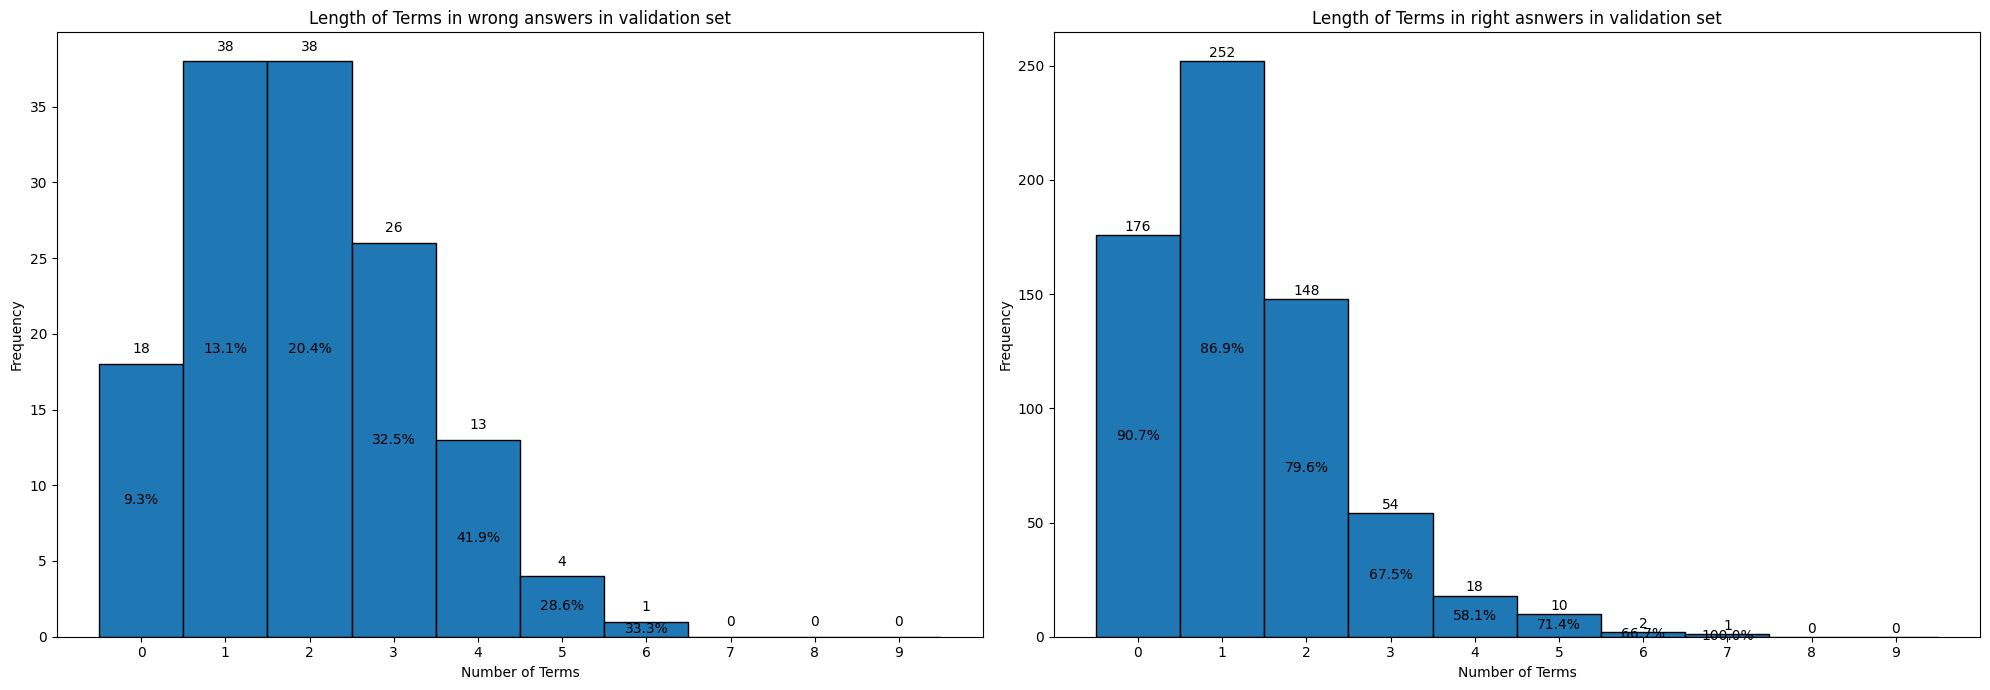

In [32]:
import matplotlib.pyplot as plt

# Calculate the length of terms for validation_set_same and validation_set_diff
test_set_same['terms_length'] = test_set_same['terms'].apply(len)
test_set_diff['terms_length'] = test_set_diff['terms'].apply(len)

# Adjust terms_length for 'noaspectterm'
test_set_same['terms_length'] = test_set_same.apply(lambda row: 0 if row['terms'] == ['noaspectterm'] else row['terms_length'], axis=1)
test_set_diff['terms_length'] = test_set_diff.apply(lambda row: 0 if row['terms'] == ['noaspectterm'] else row['terms_length'], axis=1)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))

# Plot for validation_set_diff
axes[0].hist(test_set_diff['terms_length'], bins=[i - 0.5 for i in range(0, 11)], edgecolor='black')
axes[0].set_xticks(range(0, 10))
axes[0].set_title('Length of Terms in wrong answers in validation set')
axes[0].set_xlabel('Number of Terms')
axes[0].set_ylabel('Frequency')

# Plot for validation_set_same
axes[1].hist(test_set_same['terms_length'], bins=[i - 0.5 for i in range(0, 11)], edgecolor='black')
axes[1].set_xticks(range(0, 10))
axes[1].set_title('Length of Terms in right asnwers in validation set')
axes[1].set_xlabel('Number of Terms')
axes[1].set_ylabel('Frequency')

# Add number on top of each bar for validation_set_diff
for i in range(len(axes[0].patches)):
    axes[0].text(axes[0].patches[i].get_x() + axes[0].patches[i].get_width() / 2, 
                 axes[0].patches[i].get_height() + 0.5, 
                 str(int(axes[0].patches[i].get_height())), 
                 ha='center', va='bottom')

# Add number on top of each bar for validation_set_same
for i in range(len(axes[1].patches)):
    axes[1].text(axes[1].patches[i].get_x() + axes[1].patches[i].get_width() / 2, 
                 axes[1].patches[i].get_height() + 0.5, 
                 str(int(axes[1].patches[i].get_height())), 
                 ha='center', va='bottom')
    
# Add ratio in the middle of each bar for validation_set_diff
# Add ratio in the middle of each bar for validation_set_diff
for i in range(len(axes[0].patches)):
    height = axes[0].patches[i].get_height()
    total_height = height + axes[1].patches[i].get_height()
    ratio = height / total_height if total_height != 0 else 0
    if ratio == 0:
        continue 
    ratio = ratio * 100
    axes[0].text(axes[0].patches[i].get_x() + axes[0].patches[i].get_width() / 2, 
                 height / 2, 
                 f'{ratio:.1f}%', 
                 ha='center', va='center')

# Add ratio in the middle of each bar for validation_set_same
for i in range(len(axes[1].patches)):
    height = axes[1].patches[i].get_height()
    total_height = height + axes[0].patches[i].get_height()
    ratio = height / total_height if total_height != 0 else 0
    if ratio == 0:
        continue 
    ratio = ratio * 100
    axes[1].text(axes[1].patches[i].get_x() + axes[1].patches[i].get_width() / 2, 
                 height / 2, 
                 f'{ratio:.1f}%', 
                 ha='center', va='center')

# Show the plots
plt.tight_layout()
plt.show()
# Add number on top of each bar for validation_set_diff


/tmp/ipykernel_1305864/601352783.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_same['num_words'] = filtered_df_same['raw_text'].apply(lambda x: len(x.split()))
/tmp/ipykernel_1305864/601352783.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_diff['num_words'] = filtered_df_diff['raw_text'].apply(lambda x: len(x.split()))


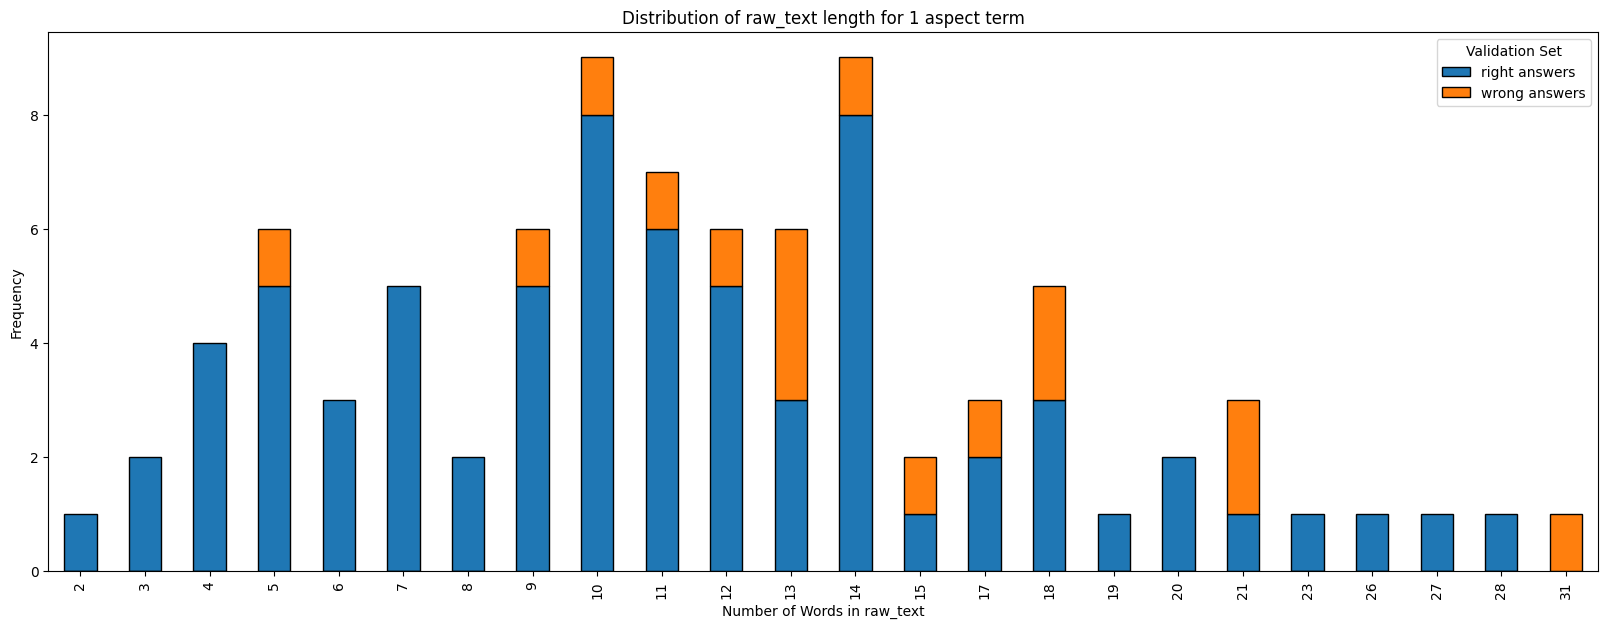

In [37]:
# Filter the dataframes
filtered_df_same = validation_set_same[validation_set_same['terms_length'] == 1]
filtered_df_diff = validation_set_diff[validation_set_diff['terms_length'] == 1]

# Calculate the number of words in each sentence
filtered_df_same['num_words'] = filtered_df_same['raw_text'].apply(lambda x: len(x.split()))
filtered_df_diff['num_words'] = filtered_df_diff['raw_text'].apply(lambda x: len(x.split()))

# Get the distribution of the number of words
distribution_same = filtered_df_same['num_words'].value_counts().sort_index()
distribution_diff = filtered_df_diff['num_words'].value_counts().sort_index()

# Create a DataFrame for the stacked bar chart
distribution_df = pd.DataFrame({
    'right answers': distribution_same,
    'wrong answers': distribution_diff
}).fillna(0)

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(20, 7))
distribution_df.plot(kind='bar', stacked=True, edgecolor='black', ax=ax)
plt.xlabel('Number of Words in raw_text')
plt.ylabel('Frequency')
plt.title('Distribution of raw_text length for 1 aspect term')
plt.legend(title='Validation Set')
plt.show()

/tmp/ipykernel_1305864/2034644229.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_set_same['num_words'] = validation_set_same['raw_text'].apply(lambda x: len(x.split()))
/tmp/ipykernel_1305864/2034644229.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_set_diff['num_words'] = validation_set_diff['raw_text'].apply(lambda x: len(x.split()))


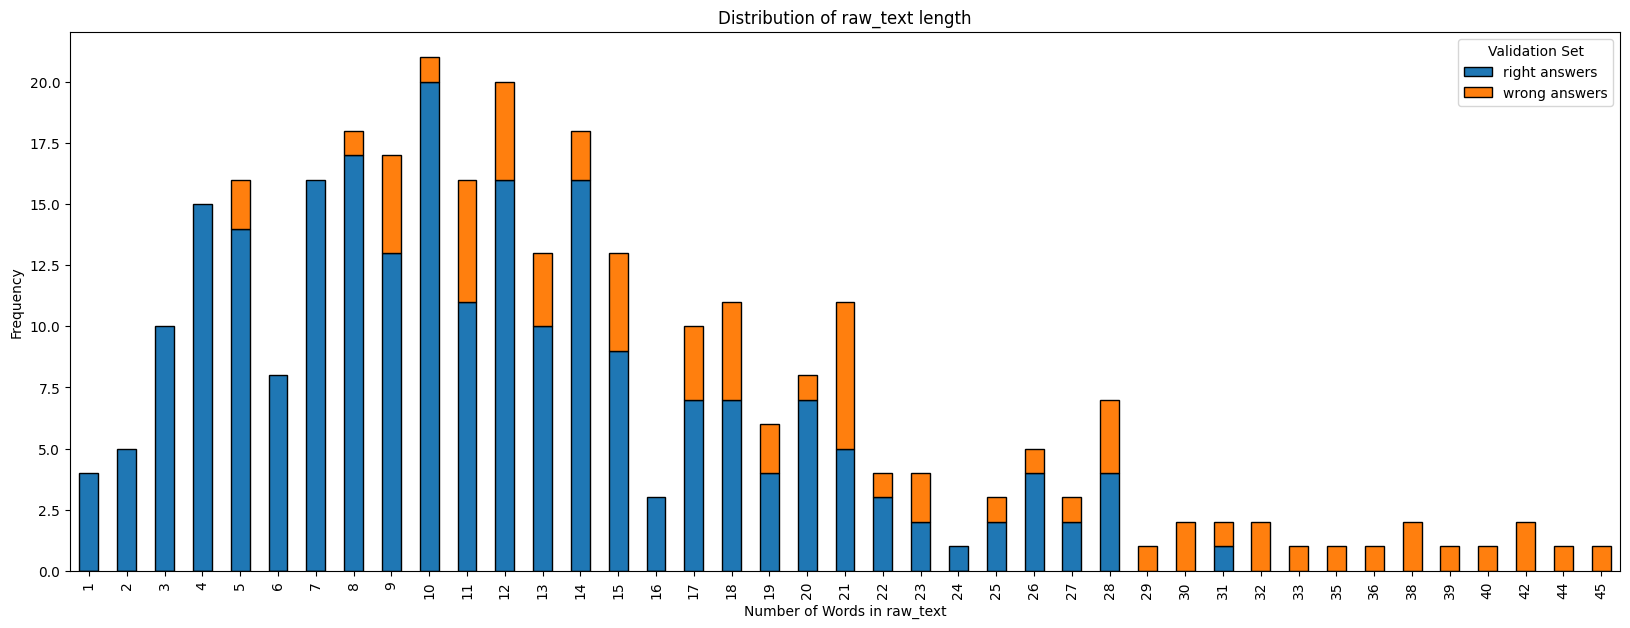

In [ ]:
import matplotlib.pyplot as plt


# Calculate the number of words in each sentence
validation_set_same['num_words'] = validation_set_same['raw_text'].apply(lambda x: len(x.split()))
validation_set_diff['num_words'] = validation_set_diff['raw_text'].apply(lambda x: len(x.split()))

# Get the distribution of the number of words
distribution_same = validation_set_same['num_words'].value_counts().sort_index()
distribution_diff = validation_set_diff['num_words'].value_counts().sort_index()

# Create a DataFrame for the stacked bar chart
distribution_df = pd.DataFrame({
    'right answers': distribution_same,
    'wrong answers': distribution_diff
}).fillna(0)

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(20, 7))
distribution_df.plot(kind='bar', stacked=True, edgecolor='black', ax=ax)
plt.xlabel('Number of Words in raw_text')
plt.ylabel('Frequency')
plt.title('Distribution of raw_text length')
plt.legend(title='Validation Set')
plt.show()

# Irrelevant shit

In [2]:
import os
path = '/home/s6moakba/InstructABSA/epoch_metrics/LRS_t5/14_l/ATSC/agent.csv'

def parse_epoch_address(path):

    # 1) Strip off the filename and its extension:
    filename = os.path.basename(path)         # e.g. "training_set.csv"
    base, _ext = os.path.splitext(filename)   # e.g. ("training_set", ".csv")

    # 2) The folder one level up from the file:
    task = os.path.basename(os.path.dirname(path)) 

    # 3) The folder two levels up:
    dataset = os.path.basename(
        os.path.dirname(os.path.dirname(path))
    )

    dataset_key = base + '_' + dataset

    return {
        "task": task,
        "train_key": dataset_key,
        'test_key': dataset
    }

print (parse_epoch_address(path))

{'task': 'ATSC', 'train_key': 'agent_14_l', 'test_key': '14_l'}
